# Segmentação Semântica em Ambientes Urbanos
## Dataset: CamVid | Arquitetura: U-Net + ResNet-34 | Framework: PyTorch

Pipeline completo de segmentação semântica aplicado ao dataset CamVid.
O projeto cobre desde a análise exploratória dos dados até a avaliação
do modelo treinado, com foco em boas práticas de engenharia de dados e ML.

**Requisitos:** veja `requirements.txt` na raiz do projeto.

In [2]:
# Instalação das dependências (execute apenas uma vez)
# O PyTorch deve ser instalado separadamente com suporte à sua GPU:
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

import subprocess, sys

dependencias = [
    "segmentation-models-pytorch>=0.3.3",
    "torchmetrics>=1.3.0",
    "opencv-python-headless>=4.9.0",
    "albumentations>=1.4.0",
    "tqdm>=4.66.0",
    "imagehash>=4.3.0",
    "pandas>=2.0.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.13.0",
    "scikit-learn>=1.3.0",
]

for dep in dependencias:
    subprocess.check_call([sys.executable, "-m", "pip", "install", dep, "-q"])

print("✅ Dependências instaladas com sucesso.")

✅ Dependências instaladas com sucesso.


In [28]:
# === IMPORTS ===

# Sistema
import os
import time
import platform
import warnings
from pathlib import Path
from collections import defaultdict

# Dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Imagens
import cv2
from PIL import Image
import imagehash

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import GradScaler, autocast

# Segmentação
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

# Métricas
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    MulticlassJaccardIndex,
    MulticlassF1Score,
    MulticlassAccuracy,
)

# Augmentação
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Utilitários
from tqdm import tqdm

warnings.filterwarnings("ignore")
print("✅ Imports realizados com sucesso.")

✅ Imports realizados com sucesso.


In [ ]:
# === CONFIGURAÇÃO CENTRAL ===
# Todos os parâmetros do projeto estão aqui.
# É o único lugar que precisa ser editado para adaptar o projeto.

# --- Paths ---
BASE_DIR  = Path.cwd()
DATA_DIR  = BASE_DIR / "camvid" / "CamVid"

DIR_TRAIN_IMG   = DATA_DIR / "train"
DIR_TRAIN_MSK   = DATA_DIR / "train_labels"
DIR_VAL_IMG     = DATA_DIR / "val"
DIR_VAL_MSK     = DATA_DIR / "val_labels"
DIR_TEST_IMG    = DATA_DIR / "test"
DIR_TEST_MSK    = DATA_DIR / "test_labels"
PATH_CLASS_DICT = DATA_DIR / "class_dict.csv"

# --- Hardware ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# num_workers > 0 causa erro em notebooks no Windows
# No Linux/Mac funciona normalmente com workers paralelos
NUM_WORKERS = 0 if platform.system() == "Windows" else 2

# --- Modelo ---
ENCODER         = "resnet34"
ENCODER_WEIGHTS = "imagenet"

# --- Imagem ---
IMG_HEIGHT = 320
IMG_WIDTH  = 480

# --- Treinamento ---
BATCH_SIZE               = 4
NUM_EPOCHS               = 30
LEARNING_RATE            = 1e-4
WEIGHT_DECAY             = 1e-4
PATIENCE_SCHEDULER       = 3
FACTOR_SCHEDULER         = 0.5
PATIENCE_EARLY_STOPPING  = 7
LAMBDA_DICE              = 0.5
NUM_CLASSES              = 21  # Classes após a remoção de classes com representação insuficiente
IGNORE_INDEX             = 21  # índice reservado para Void e classes removidas

# --- Saída ---
BEST_MODEL_PATH = BASE_DIR / f"best_model_{ENCODER}.pth"

# --- Reprodutibilidade ---
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"✅ Configuração carregada.")
print(f"   Dispositivo  : {DEVICE}")
print(f"   Encoder      : {ENCODER}")
print(f"   Resolução    : {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"   Batch Size   : {BATCH_SIZE}")
print(f"   Épocas       : {NUM_EPOCHS}")
print(f"   Dados em     : {DATA_DIR}")
print(f"   Modelo em    : {BEST_MODEL_PATH}")



✅ Configuração carregada.
   Dispositivo  : cuda
   Encoder      : resnet34
   Resolução    : 320x480
   Batch Size   : 4
   Épocas       : 30
   Dados em     : c:\Users\Fileto\Segmentacao_ambientes_naturais\camvid\CamVid
   Modelo em    : c:\Users\Fileto\Segmentacao_ambientes_naturais\best_model_resnet34.pth


## 1. Análise Exploratória dos Dados (EDA)

Antes de treinar qualquer modelo, precisamos entender profundamente os dados.
Essa seção responde perguntas essenciais:
- Quantas imagens temos por split?
- Existem imagens duplicadas?
- Quais classes existem e como estão distribuídas?
- O dataset é balanceado ou há classes dominantes?

Essas respostas guiam decisões críticas: quais classes manter,
como lidar com desequilíbrio, e o que esperar do modelo.

In [5]:
# === DICIONÁRIO DE CLASSES ===
# O arquivo class_dict.csv mapeia cada classe ao seu nome e cor RGB na máscara.

class_df = pd.read_csv(PATH_CLASS_DICT)
print(f"Total de classes no dataset: {len(class_df)}\n")
print(class_df.to_string(index=False))

Total de classes no dataset: 32

             name   r   g   b
           Animal  64 128  64
          Archway 192   0 128
        Bicyclist   0 128 192
           Bridge   0 128  64
         Building 128   0   0
              Car  64   0 128
  CartLuggagePram  64   0 192
            Child 192 128  64
      Column_Pole 192 192 128
            Fence  64  64 128
     LaneMkgsDriv 128   0 192
  LaneMkgsNonDriv 192   0  64
        Misc_Text 128 128  64
MotorcycleScooter 192   0 192
      OtherMoving 128  64  64
     ParkingBlock  64 192 128
       Pedestrian  64  64   0
             Road 128  64 128
     RoadShoulder 128 128 192
         Sidewalk   0   0 192
       SignSymbol 192 128 128
              Sky 128 128 128
   SUVPickupTruck  64 128 192
      TrafficCone   0   0  64
     TrafficLight   0  64  64
            Train 192  64 128
             Tree 128 128   0
        Truck_Bus 192 128 192
           Tunnel  64   0  64
   VegetationMisc 192 192   0
             Void   0   0   0
       

In [6]:
# === CONTAGEM DE IMAGENS POR SPLIT ===

splits = {
    "Treino" : (DIR_TRAIN_IMG, DIR_TRAIN_MSK),
    "Validação": (DIR_VAL_IMG,   DIR_VAL_MSK),
    "Teste"  : (DIR_TEST_IMG,  DIR_TEST_MSK),
}

print(f"{'Split':<12} {'Imagens':>8} {'Máscaras':>10} {'Consistente':>13}")
print("-" * 46)

total_imgs = 0
for split, (img_dir, msk_dir) in splits.items():
    imgs = sorted(img_dir.glob("*.png"))
    msks = sorted(msk_dir.glob("*.png"))
    consistent = "✅" if len(imgs) == len(msks) else "❌"
    print(f"{split:<12} {len(imgs):>8} {len(msks):>10} {consistent:>13}")
    total_imgs += len(imgs)

print("-" * 46)
print(f"{'TOTAL':<12} {total_imgs:>8}")

Split         Imagens   Máscaras   Consistente
----------------------------------------------
Treino            369        369             ✅
Validação         100        100             ✅
Teste             232        232             ✅
----------------------------------------------
TOTAL             701


In [7]:
# === VERIFICAÇÃO DE DUPLICATAS ===
# Imagens duplicadas no treino inflam métricas artificialmente.
# Usamos perceptual hashing — técnica que detecta imagens visualmente
# idênticas ou muito similares, mesmo com pequenas diferenças de compressão.

def encontrar_duplicatas(img_dir):
    hashes = defaultdict(list)
    for img_path in sorted(img_dir.glob("*.png")):
        h = str(imagehash.phash(Image.open(img_path)))
        hashes[h].append(img_path.name)
    return {h: nomes for h, nomes in hashes.items() if len(nomes) > 1}

for split, (img_dir, _) in splits.items():
    duplicatas = encontrar_duplicatas(img_dir)
    if duplicatas:
        print(f"⚠️  {split}: {len(duplicatas)} grupos de duplicatas encontrados")
        for grupo in duplicatas.values():
            print(f"   → {grupo}")
    else:
        print(f"✅ {split}: nenhuma duplicata encontrada")

⚠️  Treino: 10 grupos de duplicatas encontrados
   → ['0001TP_009480.png', '0001TP_009510.png']
   → ['0016E5_04860.png', '0016E5_04890.png', '0016E5_04950.png']
   → ['0016E5_07977.png', '0016E5_07981.png']
   → ['0016E5_07999.png', '0016E5_08001.png']
   → ['0016E5_08013.png', '0016E5_08015.png', '0016E5_08017.png', '0016E5_08019.png']
   → ['0016E5_08021.png', '0016E5_08023.png']
   → ['0016E5_08033.png', '0016E5_08035.png']
   → ['0016E5_08155.png', '0016E5_08157.png']
   → ['Seq05VD_f01920.png', 'Seq05VD_f02130.png', 'Seq05VD_f02160.png', 'Seq05VD_f02190.png']
   → ['Seq05VD_f01950.png', 'Seq05VD_f02100.png', 'Seq05VD_f02220.png', 'Seq05VD_f02250.png', 'Seq05VD_f02490.png', 'Seq05VD_f02520.png', 'Seq05VD_f02550.png', 'Seq05VD_f02730.png', 'Seq05VD_f02850.png']
⚠️  Validação: 3 grupos de duplicatas encontrados
   → ['0001TP_009270.png', '0001TP_009300.png']
   → ['0016E5_07989.png', '0016E5_07991.png']
   → ['Seq05VD_f02280.png', 'Seq05VD_f02310.png', 'Seq05VD_f02340.png']
⚠️  Test

### Tratamento de Duplicatas

O CamVid foi extraído de vídeos urbanos contínuos. Frames consecutivos
capturados em cenas estáticas geram imagens perceptualmente idênticas.

Foram encontrados 10 grupos de duplicatas no treino, todos dentro do
próprio split — sem contaminação entre treino, validação e teste.

**Decisão:** remover duplicatas do treino (manter o primeiro frame de
cada grupo). Validação e teste são mantidos intactos — por convenção,
conjuntos de avaliação não são modificados após a divisão original.

In [14]:
# === BACKUP DO DATASET ORIGINAL ===
# Criamos uma cópia do dataset antes de qualquer modificação.
# Se precisar reverter, basta copiar camvid_backup de volta.

import shutil

BACKUP_DIR = BASE_DIR / "camvid_backup"

if BACKUP_DIR.exists():
    print(f"✅ Backup já existe em: {BACKUP_DIR}")
else:
    print("Criando backup do dataset original (pode demorar alguns segundos)...")
    shutil.copytree(DATA_DIR, BACKUP_DIR)
    print(f"✅ Backup criado em: {BACKUP_DIR}")

Criando backup do dataset original (pode demorar alguns segundos)...
✅ Backup criado em: c:\Users\Fileto\Segmentacao_ambientes_naturais\camvid_backup


In [15]:
# === REMOÇÃO DE DUPLICATAS DO TREINO ===

def remover_duplicatas(img_dir, msk_dir):
    hashes = defaultdict(list)
    for img_path in sorted(img_dir.glob("*.png")):
        h = str(imagehash.phash(Image.open(img_path)))
        hashes[h].append(img_path)

    removidos = []
    for grupo in hashes.values():
        if len(grupo) > 1:
            # Mantém o primeiro frame, remove os demais
            for img_path in grupo[1:]:
                msk_path = msk_dir / (img_path.stem + "_L.png")
                img_path.unlink()
                if msk_path.exists():
                    msk_path.unlink()
                removidos.append(img_path.name)

    return removidos

print("Removendo duplicatas do conjunto de treino...")
removidos = remover_duplicatas(DIR_TRAIN_IMG, DIR_TRAIN_MSK)

print(f"\n{len(removidos)} imagens removidas:")
for nome in removidos:
    print(f"   → {nome}")

# Confirma novo total
restantes = len(list(DIR_TRAIN_IMG.glob("*.png")))
print(f"\n✅ Treino após limpeza: {restantes} imagens")

Removendo duplicatas do conjunto de treino...

22 imagens removidas:
   → 0001TP_009510.png
   → 0016E5_04890.png
   → 0016E5_04950.png
   → 0016E5_07981.png
   → 0016E5_08001.png
   → 0016E5_08015.png
   → 0016E5_08017.png
   → 0016E5_08019.png
   → 0016E5_08023.png
   → 0016E5_08035.png
   → 0016E5_08157.png
   → Seq05VD_f02130.png
   → Seq05VD_f02160.png
   → Seq05VD_f02190.png
   → Seq05VD_f02100.png
   → Seq05VD_f02220.png
   → Seq05VD_f02250.png
   → Seq05VD_f02490.png
   → Seq05VD_f02520.png
   → Seq05VD_f02550.png
   → Seq05VD_f02730.png
   → Seq05VD_f02850.png

✅ Treino após limpeza: 347 imagens


### Visualização de Amostras
Inspecionamos visualmente imagens e suas máscaras para entender
a qualidade das anotações e o tipo de cena do dataset.

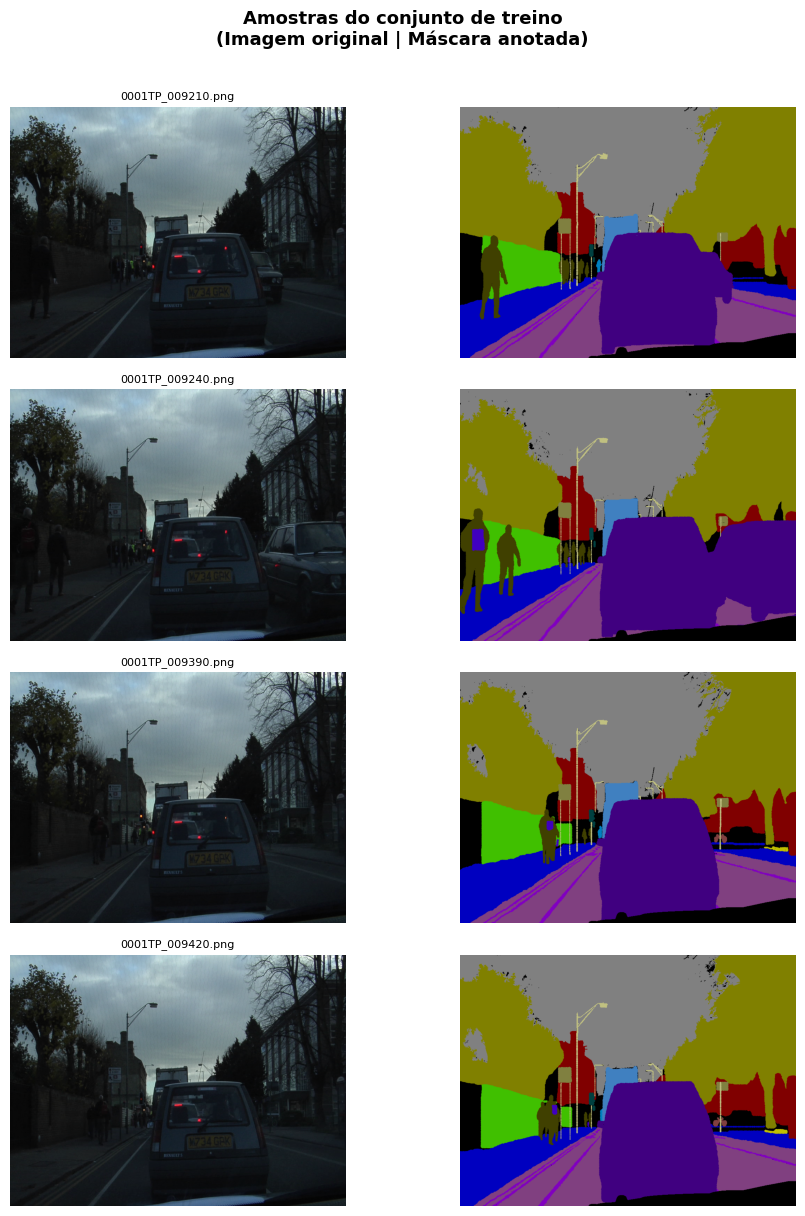

In [16]:
def carregar_amostra(img_dir, msk_dir, n=4):
    imgs = sorted(img_dir.glob("*.png"))[:n]
    fig, axes = plt.subplots(n, 2, figsize=(10, n * 3))
    fig.suptitle("Amostras do conjunto de treino\n(Imagem original | Máscara anotada)",
                 fontsize=13, fontweight="bold", y=1.01)

    for i, img_path in enumerate(imgs):
        # Máscaras do CamVid têm sufixo _L no nome
        msk_path = msk_dir / (img_path.stem + "_L.png")
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        msk = cv2.cvtColor(cv2.imread(str(msk_path)), cv2.COLOR_BGR2RGB)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(img_path.name, fontsize=8)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(msk)
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

carregar_amostra(DIR_TRAIN_IMG, DIR_TRAIN_MSK)

In [17]:
# === DISTRIBUIÇÃO DE PIXELS POR CLASSE ===
# Contar imagens por classe diz pouco. O que realmente importa é
# QUANTOS PIXELS cada classe ocupa — isso revela o verdadeiro
# desequilíbrio do dataset e guia decisões de treinamento.

# Mapeia cor RGB → nome da classe
cor_para_classe = {
    (int(r), int(g), int(b)): nome
    for _, (nome, r, g, b) in class_df.iterrows()
}

def contar_pixels_por_classe(msk_dir, cor_para_classe):
    contagem = defaultdict(int)
    for msk_path in tqdm(sorted(msk_dir.glob("*.png")), desc="Analisando máscaras"):
        msk = np.array(Image.open(msk_path).convert("RGB"))
        h, w, _ = msk.shape
        pixels = msk.reshape(-1, 3)
        for pixel in pixels:
            chave = tuple(pixel)
            if chave in cor_para_classe:
                contagem[cor_para_classe[chave]] += 1
    return contagem

print("Analisando distribuição de pixels no conjunto de treino...")
contagem_pixels = contar_pixels_por_classe(DIR_TRAIN_MSK, cor_para_classe)

# Transforma em DataFrame ordenado
df_pixels = pd.DataFrame(
    list(contagem_pixels.items()),
    columns=["Classe", "Total de Pixels"]
).sort_values("Total de Pixels", ascending=False).reset_index(drop=True)

df_pixels["Percentual (%)"] = (df_pixels["Total de Pixels"] / df_pixels["Total de Pixels"].sum() * 100).round(2)
print(df_pixels.to_string(index=False))

Analisando distribuição de pixels no conjunto de treino...


Analisando máscaras: 100%|██████████| 347/347 [05:22<00:00,  1.07it/s]

           Classe  Total de Pixels  Percentual (%)
             Road         68864376           28.71
         Building         53778258           22.42
              Sky         36794028           15.34
             Tree         24470837           10.20
         Sidewalk         15735164            6.56
              Car          7729605            3.22
             Void          6473546            2.70
     LaneMkgsDriv          4264388            1.78
            Fence          4114878            1.72
             Wall          3042926            1.27
      Column_Pole          2414608            1.01
   VegetationMisc          2084167            0.87
        Misc_Text          1616401            0.67
       Pedestrian          1485416            0.62
   SUVPickupTruck          1342674            0.56
      OtherMoving          1168463            0.49
        Bicyclist          1089306            0.45
     ParkingBlock           853739            0.36
     TrafficLight           740

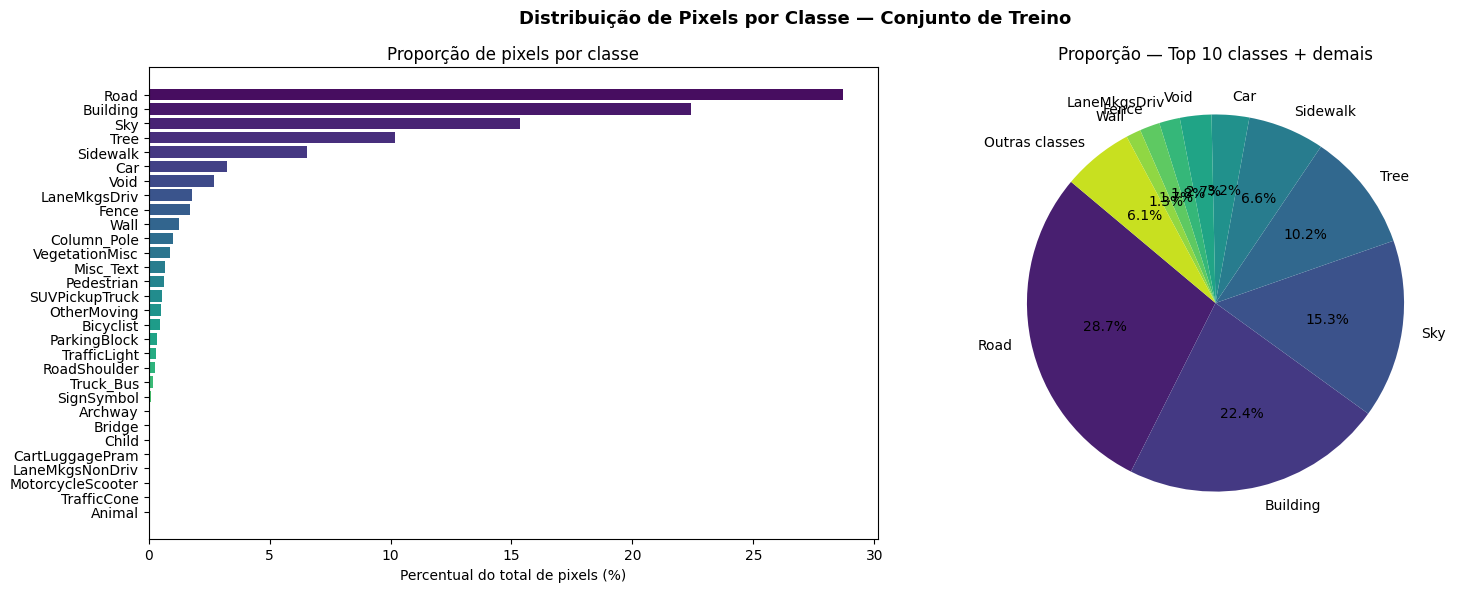

In [18]:
# === VISUALIZAÇÃO DO DESEQUILÍBRIO ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Distribuição de Pixels por Classe — Conjunto de Treino",
             fontsize=13, fontweight="bold")

# Gráfico de barras
cores = sns.color_palette("viridis", len(df_pixels))
axes[0].barh(df_pixels["Classe"], df_pixels["Percentual (%)"], color=cores)
axes[0].set_xlabel("Percentual do total de pixels (%)")
axes[0].set_title("Proporção de pixels por classe")
axes[0].invert_yaxis()

# Gráfico de pizza (top 10 + outros)
top10 = df_pixels.head(10).copy()
outros = pd.DataFrame([{
    "Classe": "Outras classes",
    "Percentual (%)": df_pixels.iloc[10:]["Percentual (%)"].sum()
}])
df_pizza = pd.concat([top10, outros], ignore_index=True)

axes[1].pie(
    df_pizza["Percentual (%)"],
    labels=df_pizza["Classe"],
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("viridis", len(df_pizza))
)
axes[1].set_title("Proporção — Top 10 classes + demais")

plt.tight_layout()
plt.show()

In [19]:
# === SELEÇÃO DE CLASSES ===
# Com base na análise de pixels, removemos classes com representação
# insignificante — menos de 0.1% dos pixels totais de treino.
# Essas classes prejudicam o treinamento sem contribuir com aprendizado.
# A classe "Void" representa regiões sem anotação e será ignorada
# durante treino e avaliação (ignore_index).

LIMIAR_PERCENTUAL = 0.1  # classes com menos de 0.1% dos pixels são removidas

classes_removidas = df_pixels[df_pixels["Percentual (%)"] < LIMIAR_PERCENTUAL]["Classe"].tolist()
classes_validas   = df_pixels[df_pixels["Percentual (%)"] >= LIMIAR_PERCENTUAL]["Classe"].tolist()

# Void é tratada separadamente como ignore_index
VOID_CLASS = "Void"
if VOID_CLASS in classes_validas:
    classes_validas.remove(VOID_CLASS)

print(f"Classes removidas ({len(classes_removidas)}) — abaixo de {LIMIAR_PERCENTUAL}% dos pixels:")
for c in classes_removidas:
    pct = df_pixels[df_pixels["Classe"] == c]["Percentual (%)"].values[0]
    print(f"   → {c}: {pct:.4f}%")

print(f"\nClasse ignorada no treino: '{VOID_CLASS}' (regiões sem anotação)")
print(f"\nClasses mantidas para treinamento: {len(classes_validas)}")
for i, c in enumerate(classes_validas):
    pct = df_pixels[df_pixels["Classe"] == c]["Percentual (%)"].values[0]
    print(f"   {i:>2}. {c:<25} {pct:.2f}%")

Classes removidas (8) — abaixo de 0.1% dos pixels:
   → Archway: 0.0500%
   → Bridge: 0.0500%
   → Child: 0.0300%
   → CartLuggagePram: 0.0300%
   → LaneMkgsNonDriv: 0.0100%
   → MotorcycleScooter: 0.0100%
   → TrafficCone: 0.0000%
   → Animal: 0.0000%

Classe ignorada no treino: 'Void' (regiões sem anotação)

Classes mantidas para treinamento: 21
    0. Road                      28.71%
    1. Building                  22.42%
    2. Sky                       15.34%
    3. Tree                      10.20%
    4. Sidewalk                  6.56%
    5. Car                       3.22%
    6. LaneMkgsDriv              1.78%
    7. Fence                     1.72%
    8. Wall                      1.27%
    9. Column_Pole               1.01%
   10. VegetationMisc            0.87%
   11. Misc_Text                 0.67%
   12. Pedestrian                0.62%
   13. SUVPickupTruck            0.56%
   14. OtherMoving               0.49%
   15. Bicyclist                 0.45%
   16. ParkingBlock   

## 2. Preparação dos Dados

Com o dataset analisado e limpo, construímos o pipeline de dados:

1. **Mapeamento de classes** — converte cores RGB das máscaras em índices numéricos
2. **Pesos de classe** — compensa o desequilíbrio severo entre classes
3. **Dataset customizado** — carrega e transforma imagens e máscaras
4. **Augmentações** — aumenta a diversidade do treino artificialmente
5. **DataLoaders** — organiza os dados em batches para o treinamento

In [22]:
# === MAPEAMENTO DE CLASSES ===
# Convertemos cores RGB das máscaras em índices numéricos (0 a 20).
# Void e classes removidas recebem IGNORE_INDEX e são ignorados
# durante treino e avaliação.

# Classes válidas na ordem da análise de pixels
CLASSES_VALIDAS = [
    "Road", "Building", "Sky", "Tree", "Sidewalk", "Car",
    "LaneMkgsDriv", "Fence", "Wall", "Column_Pole", "VegetationMisc",
    "Misc_Text", "Pedestrian", "SUVPickupTruck", "OtherMoving",
    "Bicyclist", "ParkingBlock", "TrafficLight", "RoadShoulder",
    "Truck_Bus", "SignSymbol"
]

# Dicionário: nome da classe → índice
classe_para_idx = {nome: idx for idx, nome in enumerate(CLASSES_VALIDAS)}

# Dicionário: cor RGB → índice (IGNORE_INDEX para Void e removidas)
cor_para_idx = {}
for _, row in class_df.iterrows():
    nome = row["name"]
    cor  = (int(row["r"]), int(row["g"]), int(row["b"]))
    if nome in classe_para_idx:
        cor_para_idx[cor] = classe_para_idx[nome]
    else:
        cor_para_idx[cor] = IGNORE_INDEX  # Void e classes removidas

print(f"Classes mapeadas : {len(classe_para_idx)}")
print(f"Cores no mapa    : {len(cor_para_idx)}")
print(f"Índice ignorado  : {IGNORE_INDEX} (Void + classes removidas)\n")

# === PESOS DE CLASSE ===
# Compensamos o desequilíbrio usando frequência inversa:
# classes raras recebem peso maior, classes dominantes recebem peso menor.
# Isso evita que o modelo aprenda apenas a segmentar Road e Building.

frequencias = np.array([
    df_pixels[df_pixels["Classe"] == c]["Percentual (%)"].values[0]
    for c in CLASSES_VALIDAS
])

pesos = 1.0 / (frequencias + 1e-6)           # frequência inversa
pesos = pesos / pesos.sum() * NUM_CLASSES     # normalização

CLASS_WEIGHTS = torch.tensor(pesos, dtype=torch.float32).to(DEVICE)

print("Pesos de classe calculados:")
for nome, peso, freq in zip(CLASSES_VALIDAS, pesos, frequencias):
    print(f"  {nome:<20} freq: {freq:5.2f}%   peso: {peso:.4f}")

Classes mapeadas : 21
Cores no mapa    : 32
Índice ignorado  : 21 (Void + classes removidas)

Pesos de classe calculados:
  Road                 freq: 28.71%   peso: 0.0192
  Building             freq: 22.42%   peso: 0.0246
  Sky                  freq: 15.34%   peso: 0.0359
  Tree                 freq: 10.20%   peso: 0.0540
  Sidewalk             freq:  6.56%   peso: 0.0839
  Car                  freq:  3.22%   peso: 0.1710
  LaneMkgsDriv         freq:  1.78%   peso: 0.3094
  Fence                freq:  1.72%   peso: 0.3202
  Wall                 freq:  1.27%   peso: 0.4336
  Column_Pole          freq:  1.01%   peso: 0.5452
  VegetationMisc       freq:  0.87%   peso: 0.6330
  Misc_Text            freq:  0.67%   peso: 0.8219
  Pedestrian           freq:  0.62%   peso: 0.8882
  SUVPickupTruck       freq:  0.56%   peso: 0.9834
  OtherMoving          freq:  0.49%   peso: 1.1239
  Bicyclist            freq:  0.45%   peso: 1.2238
  ParkingBlock         freq:  0.36%   peso: 1.5297
  TrafficLi

In [23]:
# === CONVERSÃO DE MÁSCARA RGB → ÍNDICES ===
# Cada pixel da máscara tem uma cor RGB que representa uma classe.
# Convertemos para uma matriz 2D onde cada pixel é o índice da classe.

def mask_rgb_para_indices(mask_rgb: np.ndarray) -> np.ndarray:
    """
    Converte máscara RGB (H, W, 3) em mapa de índices (H, W).
    Pixels sem correspondência recebem IGNORE_INDEX.
    """
    h, w, _ = mask_rgb.shape
    mask_idx = np.full((h, w), IGNORE_INDEX, dtype=np.int64)

    for cor, idx in cor_para_idx.items():
        coincide = np.all(mask_rgb == cor, axis=2)
        mask_idx[coincide] = idx

    return mask_idx

In [36]:
# === DATASET CUSTOMIZADO ===
# A classe CamVidDataset herda de torch.utils.data.Dataset e implementa
# três métodos obrigatórios: __init__, __len__ e __getitem__.

class CamVidDataset(Dataset):
    def __init__(self, img_dir, msk_dir, transform=None):
        """
        img_dir   : pasta com as imagens originais
        msk_dir   : pasta com as máscaras anotadas
        transform : pipeline de augmentação (albumentations)
        """
        self.img_paths = sorted(img_dir.glob("*.png"))
        self.msk_dir   = msk_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        msk_path = self.msk_dir / (img_path.stem + "_L.png")

        img     = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        msk_rgb = np.array(Image.open(msk_path).convert("RGB"))
        msk     = mask_rgb_para_indices(msk_rgb)

        if self.transform:
            aug = self.transform(image=img, mask=msk)
            img = aug["image"]
            msk = aug["mask"]
        else:
            img = ToTensorV2()(image=img)["image"]
            msk = torch.tensor(msk, dtype=torch.long)

        # REMOVIDO: img = img.float() / 255.0
        # A.Normalize já faz essa divisão internamente
        return img.float(), msk.long()

In [25]:
# === AUGMENTAÇÕES ===
# Augmentações aumentam artificialmente a diversidade do treino,
# tornando o modelo mais robusto a variações do mundo real.
# Aplicadas APENAS no treino — validação e teste usam só redimensionamento.

# Média e desvio padrão do ImageNet (usados pelo encoder pré-treinado)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

transform_treino = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),

    # Espelhamento horizontal — simula direção oposta de tráfego
    A.HorizontalFlip(p=0.5),

    # Variações de brilho e contraste — simula diferentes condições de luz
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),

    # Leve distorção geométrica — simula variações de câmera
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.3),

    # Normalização com média e desvio padrão do ImageNet
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

transform_val_teste = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

In [38]:
# === DATALOADERS ===
# O DataLoader divide o dataset em batches e gerencia o carregamento
# paralelo dos dados durante o treinamento.

ds_treino = CamVidDataset(DIR_TRAIN_IMG, DIR_TRAIN_MSK, transform=transform_treino)
ds_val    = CamVidDataset(DIR_VAL_IMG,   DIR_VAL_MSK,   transform=transform_val_teste)
ds_teste  = CamVidDataset(DIR_TEST_IMG,  DIR_TEST_MSK,  transform=transform_val_teste)

dl_treino = DataLoader(ds_treino, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
dl_val    = DataLoader(ds_val,    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
dl_teste  = DataLoader(ds_teste,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Treino    : {len(ds_treino):>4} imagens  |  {len(dl_treino):>3} batches")
print(f"Validação : {len(ds_val):>4} imagens  |  {len(dl_val):>3} batches")
print(f"Teste     : {len(ds_teste):>4} imagens  |  {len(dl_teste):>3} batches")

Treino    :  347 imagens  |   87 batches
Validação :  100 imagens  |   25 batches
Teste     :  232 imagens  |   58 batches


Shape das imagens : torch.Size([4, 3, 320, 480])   dtype: torch.float32
Shape das máscaras: torch.Size([4, 320, 480])   dtype: torch.int64
Valor mín/máx img : -2.118 / 2.640
Índices únicos na máscara: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 21]


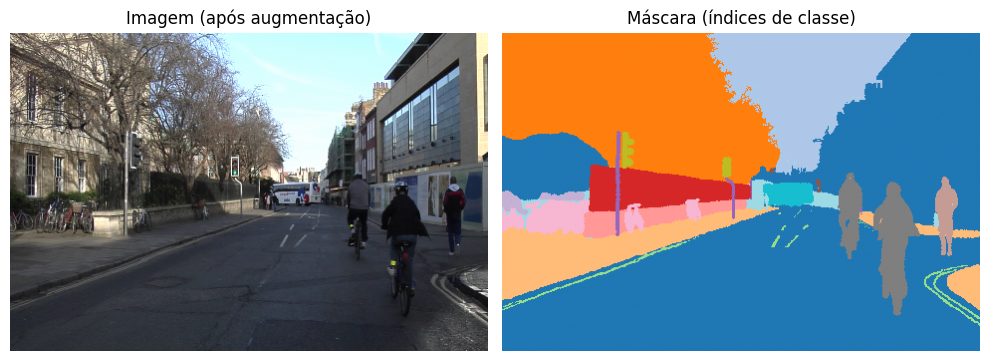

In [39]:
# === VERIFICAÇÃO DO DATALOADER ===
# Confirmamos que shapes, tipos e valores estão corretos antes de treinar.

imgs, msks = next(iter(dl_treino))

print(f"Shape das imagens : {imgs.shape}   dtype: {imgs.dtype}")
print(f"Shape das máscaras: {msks.shape}   dtype: {msks.dtype}")
print(f"Valor mín/máx img : {imgs.min():.3f} / {imgs.max():.3f}")
print(f"Índices únicos na máscara: {msks.unique().tolist()}")

# Visualiza um exemplo do batch
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
img_vis = imgs[0].permute(1, 2, 0).numpy()
img_vis = (img_vis * STD + MEAN).clip(0, 1)

axes[0].imshow(img_vis)
axes[0].set_title("Imagem (após augmentação)")
axes[0].axis("off")

axes[1].imshow(msks[0].numpy(), cmap="tab20", vmin=0, vmax=NUM_CLASSES)
axes[1].set_title("Máscara (índices de classe)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 3. Modelo

### Arquitetura: U-Net
A U-Net é uma arquitetura de rede neural projetada especificamente para
segmentação semântica. Ela é dividida em duas partes:

- **Encoder (descida):** extrai características progressivamente mais
  abstratas da imagem, reduzindo a resolução espacial
- **Decoder (subida):** reconstrói a resolução original combinando
  características do encoder via *skip connections*

As *skip connections* são o diferencial da U-Net — elas conectam cada
nível do encoder diretamente ao decoder correspondente, preservando
detalhes espaciais que seriam perdidos na compressão.

### Encoder: ResNet-34 com Transfer Learning
Em vez de treinar o encoder do zero, usamos pesos pré-treinados no
ImageNet — técnica chamada **Transfer Learning**. O ResNet-34 já aprendeu
a reconhecer bordas, texturas e formas em milhões de imagens. Aproveitamos
esse conhecimento e apenas ensinamos o modelo a aplicá-lo à segmentação
do CamVid.

Escolhemos o ResNet-34 em vez do ResNet-50 original por ser mais leve,
adequado aos 4GB de VRAM disponíveis, com diferença mínima de performance.

### Loss Function: Dice + Cross-Entropy
Combinamos duas funções de perda complementares:

- **Cross-Entropy Loss:** penaliza cada pixel individualmente. Recebe
  pesos de classe para compensar o desequilíbrio do dataset
- **Dice Loss:** mede a sobreposição entre predição e máscara real.
  Mais robusta a desequilíbrio de classes

A loss final é: `L = λ·Dice + (1-λ)·CrossEntropy`, com `λ = 0.5`

In [40]:
# === MODELO ===
# U-Net com encoder ResNet-34 pré-treinado no ImageNet.
# A biblioteca segmentation_models_pytorch monta a arquitetura completa
# com uma linha, incluindo skip connections e decoder.

model = smp.Unet(
    encoder_name    = ENCODER,
    encoder_weights = ENCODER_WEIGHTS,
    in_channels     = 3,
    classes         = NUM_CLASSES,
)
model = model.to(DEVICE)

# Conta parâmetros treináveis e fixos
params_treinados = sum(p.numel() for p in model.parameters() if p.requires_grad)
params_totais    = sum(p.numel() for p in model.parameters())

print(f"Modelo          : U-Net + {ENCODER.upper()}")
print(f"Parâmetros      : {params_totais:,}")
print(f"  → Treináveis  : {params_treinados:,}")
print(f"  → Fixos       : {params_totais - params_treinados:,}")
print(f"Dispositivo     : {next(model.parameters()).device}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Modelo          : U-Net + RESNET34
Parâmetros      : 24,439,269
  → Treináveis  : 24,439,269
  → Fixos       : 0
Dispositivo     : cuda:0


In [41]:
# === LOSS FUNCTION ===
# Combinamos Dice Loss e Cross-Entropy Loss.
#
# Cross-Entropy: avalia cada pixel independentemente.
#   - weight=CLASS_WEIGHTS: penaliza mais o erro em classes raras
#   - ignore_index=IGNORE_INDEX: ignora Void e classes removidas
#
# Dice Loss: avalia a sobreposição global entre predição e máscara.
#   - Mais estável com desequilíbrio de classes
#   - ignore_index: mesmo tratamento do Void
#
# A loss final pondera as duas igualmente (LAMBDA_DICE = 0.5)

criterion_ce   = nn.CrossEntropyLoss(
    weight       = CLASS_WEIGHTS,
    ignore_index = IGNORE_INDEX,
)

criterion_dice = DiceLoss(
    mode         = "multiclass",
    ignore_index = IGNORE_INDEX,
)

def loss_fn(logits, mascaras):
    """
    logits   : tensor (B, C, H, W) — saída bruta do modelo
    mascaras : tensor (B, H, W)    — índices de classe reais
    """
    loss_ce   = criterion_ce(logits, mascaras)
    loss_dice = criterion_dice(logits, mascaras)
    return LAMBDA_DICE * loss_dice + (1 - LAMBDA_DICE) * loss_ce

print("✅ Loss function configurada.")
print(f"   Dice Loss        : peso {LAMBDA_DICE}")
print(f"   Cross-Entropy    : peso {1 - LAMBDA_DICE} (com pesos de classe)")
print(f"   Ignore index     : {IGNORE_INDEX}")

✅ Loss function configurada.
   Dice Loss        : peso 0.5
   Cross-Entropy    : peso 0.5 (com pesos de classe)
   Ignore index     : 21


In [42]:
# === MÉTRICAS ===
# Usamos torchmetrics para métricas corretas em segmentação multiclasse.
#
# IoU (Intersection over Union): métrica principal em segmentação.
#   Mede a sobreposição entre predição e ground truth por classe.
#   Valor entre 0 e 1 — quanto maior, melhor.
#
# F1-Score (Dice): harmônica entre precisão e recall por classe.
#
# Accuracy: percentual de pixels classificados corretamente.
#   Menos informativa com desequilíbrio — usada como referência.
#
# average='macro': calcula a métrica por classe e tira a média,
#   dando peso igual a classes raras e dominantes.

metricas = MetricCollection({
    "iou"      : MulticlassJaccardIndex(
                    num_classes  = NUM_CLASSES,
                    ignore_index = IGNORE_INDEX,
                    average      = "macro",
                 ),
    "f1"       : MulticlassF1Score(
                    num_classes  = NUM_CLASSES,
                    ignore_index = IGNORE_INDEX,
                    average      = "macro",
                 ),
    "accuracy" : MulticlassAccuracy(
                    num_classes  = NUM_CLASSES,
                    ignore_index = IGNORE_INDEX,
                    average      = "macro",
                 ),
}).to(DEVICE)

print("✅ Métricas configuradas.")
print("   → IoU (Macro)")
print("   → F1-Score / Dice (Macro)")
print("   → Accuracy (Macro)")

✅ Métricas configuradas.
   → IoU (Macro)
   → F1-Score / Dice (Macro)
   → Accuracy (Macro)


In [45]:
# === OTIMIZADOR E SCHEDULER ===

# Adam: algoritmo de otimização adaptativo, padrão para visão computacional.
# weight_decay: regularização L2 — penaliza pesos muito grandes,
#   reduz overfitting.
optimizer = Adam(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY,
)

# ReduceLROnPlateau: reduz o learning rate quando a validação estagna.
# Se a val_loss não melhorar por PATIENCE_SCHEDULER épocas,
# multiplica o LR por FACTOR_SCHEDULER (ex: 1e-4 → 5e-5).
scheduler = ReduceLROnPlateau(
    optimizer,
    mode     = "min",
    patience = PATIENCE_SCHEDULER,
    factor   = FACTOR_SCHEDULER,
)

print("✅ Otimizador e scheduler configurados.")
print(f"   Otimizador  : Adam")
print(f"   LR inicial  : {LEARNING_RATE}")
print(f"   Weight Decay: {WEIGHT_DECAY}")
print(f"   Scheduler   : ReduceLROnPlateau")
print(f"     → Patience: {PATIENCE_SCHEDULER} épocas")
print(f"     → Fator   : {FACTOR_SCHEDULER}x")

✅ Otimizador e scheduler configurados.
   Otimizador  : Adam
   LR inicial  : 0.0001
   Weight Decay: 0.0001
   Scheduler   : ReduceLROnPlateau
     → Patience: 3 épocas
     → Fator   : 0.5x


In [46]:
# === VERIFICAÇÃO DO MODELO ===
# Passamos um batch falso pelo modelo para confirmar que os shapes
# de entrada e saída estão corretos antes de treinar.

model.eval()
with torch.no_grad():
    batch_teste  = torch.randn(BATCH_SIZE, 3, IMG_HEIGHT, IMG_WIDTH).to(DEVICE)
    saida_teste  = model(batch_teste)

print(f"Shape de entrada : {batch_teste.shape}")
print(f"Shape de saída   : {saida_teste.shape}")
print(f"\nEsperado: (batch={BATCH_SIZE}, classes={NUM_CLASSES}, H={IMG_HEIGHT}, W={IMG_WIDTH})")

assert saida_teste.shape == (BATCH_SIZE, NUM_CLASSES, IMG_HEIGHT, IMG_WIDTH), \
    "❌ Shape de saída incorreto!"

print("\n✅ Modelo verificado e pronto para treino.")

Shape de entrada : torch.Size([4, 3, 320, 480])
Shape de saída   : torch.Size([4, 21, 320, 480])

Esperado: (batch=4, classes=21, H=320, W=480)

✅ Modelo verificado e pronto para treino.


## 4. Treinamento

O loop de treinamento itera sobre o dataset por múltiplas épocas,
atualizando os pesos do modelo para minimizar a loss.

A cada época:
1. **Treino:** o modelo faz predições, calcula a loss e atualiza os pesos
2. **Validação:** avaliamos o modelo sem atualizar pesos — mede generalização
3. **Scheduler:** reduz o learning rate se a validação estagnar
4. **Early Stopping:** interrompe o treino se não houver melhora por N épocas
5. **Checkpoint:** salva o melhor modelo encontrado

**Mixed Precision (AMP):** usamos `torch.amp` para computar em float16
onde possível, reduzindo o uso de VRAM pela metade sem perda de qualidade.

In [47]:
# === EARLY STOPPING ===
# Interrompe o treino quando a val_loss para de melhorar,
# evitando overfitting e desperdício de tempo computacional.

class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        """
        patience  : épocas sem melhora antes de parar
        min_delta : melhora mínima para ser considerada progresso
        """
        self.patience   = patience
        self.min_delta  = min_delta
        self.contador   = 0
        self.melhor_loss = float("inf")
        self.parar      = False

    def __call__(self, val_loss):
        if val_loss < self.melhor_loss - self.min_delta:
            self.melhor_loss = val_loss
            self.contador    = 0
        else:
            self.contador += 1
            if self.contador >= self.patience:
                self.parar = True

In [48]:
# === FUNÇÕES DE TREINO E VALIDAÇÃO ===

def treinar_epoca(model, loader, optimizer, scaler):
    """Executa uma época de treino com Mixed Precision (AMP)."""
    model.train()
    loss_total = 0.0

    for imgs, mascaras in tqdm(loader, desc="  Treino", leave=False):
        imgs     = imgs.to(DEVICE)
        mascaras = mascaras.to(DEVICE)

        optimizer.zero_grad()

        # AMP: computa em float16 onde possível (economiza VRAM)
        with autocast(device_type="cuda"):
            logits = model(imgs)
            loss   = loss_fn(logits, mascaras)

        # Scaler evita underflow numérico do float16
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_total += loss.item()

    return loss_total / len(loader)


def validar_epoca(model, loader, metricas):
    """Executa uma época de validação sem atualizar pesos."""
    model.eval()
    loss_total = 0.0
    metricas.reset()

    with torch.no_grad():
        for imgs, mascaras in tqdm(loader, desc="  Validação", leave=False):
            imgs     = imgs.to(DEVICE)
            mascaras = mascaras.to(DEVICE)

            with autocast(device_type="cuda"):
                logits = model(imgs)
                loss   = loss_fn(logits, mascaras)

            loss_total += loss.item()

            # Converte logits em predições para as métricas
            preds = logits.argmax(dim=1)
            metricas.update(preds, mascaras)

    resultados = metricas.compute()
    return loss_total / len(loader), resultados

In [49]:
# === LOOP DE TREINAMENTO ===

scaler        = GradScaler()
early_stop    = EarlyStopping(patience=PATIENCE_EARLY_STOPPING)

historico = {
    "treino_loss" : [],
    "val_loss"    : [],
    "val_iou"     : [],
    "val_f1"      : [],
    "val_accuracy": [],
    "lr"          : [],
}

melhor_val_loss = float("inf")
tempo_inicio    = time.time()

print(f"Iniciando treino — {NUM_EPOCHS} épocas | dispositivo: {DEVICE}\n")

for epoca in range(1, NUM_EPOCHS + 1):
    t_epoca = time.time()

    # Treino
    treino_loss = treinar_epoca(model, dl_treino, optimizer, scaler)

    # Validação
    val_loss, val_metricas = validar_epoca(model, dl_val, metricas)

    # Scheduler
    scheduler.step(val_loss)
    lr_atual = optimizer.param_groups[0]["lr"]

    # Registra histórico
    historico["treino_loss"].append(treino_loss)
    historico["val_loss"].append(val_loss)
    historico["val_iou"].append(val_metricas["iou"].item())
    historico["val_f1"].append(val_metricas["f1"].item())
    historico["val_accuracy"].append(val_metricas["accuracy"].item())
    historico["lr"].append(lr_atual)

    # Salva melhor modelo
    if val_loss < melhor_val_loss:
        melhor_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        sufixo = " ← melhor modelo salvo"
    else:
        sufixo = ""

    # Log da época
    duracao = time.time() - t_epoca
    print(
        f"Época {epoca:>3}/{NUM_EPOCHS} | "
        f"Loss treino: {treino_loss:.4f} | "
        f"Loss val: {val_loss:.4f} | "
        f"IoU: {val_metricas['iou']:.4f} | "
        f"F1: {val_metricas['f1']:.4f} | "
        f"LR: {lr_atual:.2e} | "
        f"{duracao:.0f}s"
        f"{sufixo}"
    )

    # Early stopping
    early_stop(val_loss)
    if early_stop.parar:
        print(f"\n⏹ Early stopping acionado na época {epoca}.")
        break

tempo_total = time.time() - tempo_inicio
print(f"\n✅ Treino concluído em {tempo_total/60:.1f} minutos.")
print(f"   Melhor val_loss : {melhor_val_loss:.4f}")
print(f"   Modelo salvo em : {BEST_MODEL_PATH}")

Iniciando treino — 30 épocas | dispositivo: cuda



Época   1/30 | Loss treino: 1.7874 | Loss val: 1.4854 | IoU: 0.1189 | F1: 0.1814 | LR: 1.00e-04 | 281s ← melhor modelo salvo


Época   2/30 | Loss treino: 1.4431 | Loss val: 1.2463 | IoU: 0.2082 | F1: 0.3074 | LR: 1.00e-04 | 279s ← melhor modelo salvo


Época   3/30 | Loss treino: 1.2419 | Loss val: 1.1094 | IoU: 0.2794 | F1: 0.3925 | LR: 1.00e-04 | 283s ← melhor modelo salvo


Época   4/30 | Loss treino: 1.0976 | Loss val: 1.0050 | IoU: 0.3221 | F1: 0.4411 | LR: 1.00e-04 | 276s ← melhor modelo salvo


...

Época  26/30 | Loss treino: 0.3510 | Loss val: 0.6330 | IoU: 0.5670 | F1: 0.6964 | LR: 5.00e-05 | 270s


Época  27/30 | Loss treino: 0.3509 | Loss val: 0.6461 | IoU: 0.5724 | F1: 0.7033 | LR: 5.00e-05 | 274s


Época  28/30 | Loss treino: 0.3431 | Loss val: 0.6530 | IoU: 0.5852 | F1: 0.7138 | LR: 2.50e-05 | 281s


Época  29/30 | Loss treino: 0.3218 | Loss val: 0.6415 | IoU: 0.5822 | F1: 0.7107 | LR: 2.50e-05 | 276s


Época  30/30 | Loss treino: 0.3141 | Loss val: 0.6391 | IoU: 0.5893 | F1: 0.7168 | LR: 2.50e-05 | 264s

✅ Treino concluído em 138.0 minutos.
   Melhor val_loss : 0.6244
   Modelo salvo em : c:\Users\Fileto\Segmentacao_ambientes_naturais\best_model_resnet34.pth


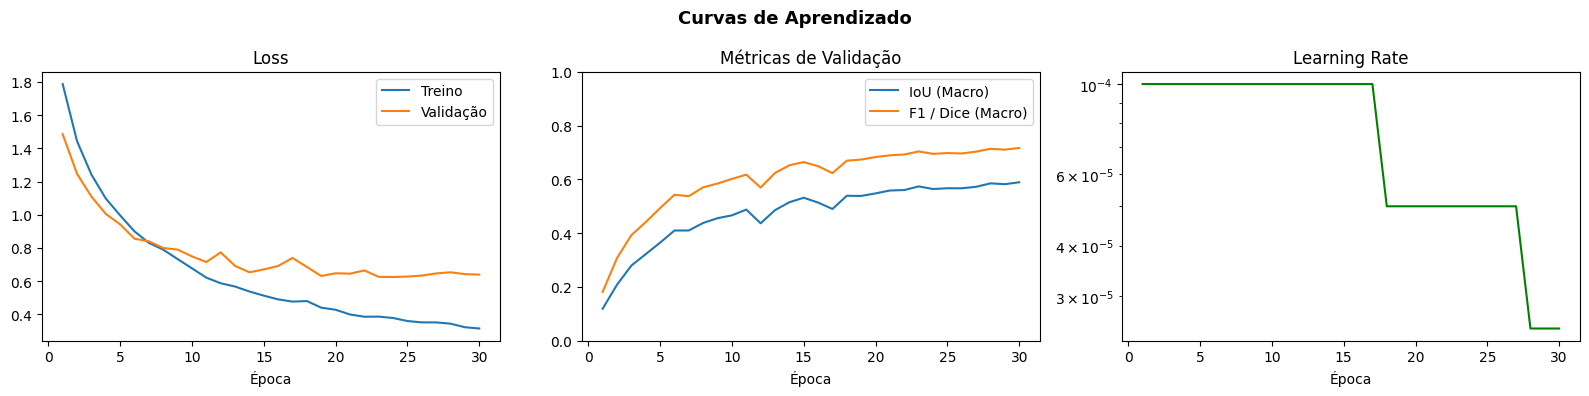

In [51]:
# === CURVAS DE APRENDIZADO ===
# Visualizamos a evolução das métricas ao longo do treino.
# Curvas de treino e validação próximas indicam boa generalização.
# Divergência indica overfitting.

epocas = range(1, len(historico["treino_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Curvas de Aprendizado", fontsize=13, fontweight="bold")

# Loss
axes[0].plot(epocas, historico["treino_loss"], label="Treino")
axes[0].plot(epocas, historico["val_loss"],    label="Validação")
axes[0].set_title("Loss")
axes[0].set_xlabel("Época")
axes[0].legend()

# IoU e F1
axes[1].plot(epocas, historico["val_iou"], label="IoU (Macro)")
axes[1].plot(epocas, historico["val_f1"],  label="F1 / Dice (Macro)")
axes[1].set_title("Métricas de Validação")
axes[1].set_xlabel("Época")
axes[1].set_ylim(0, 1)
axes[1].legend()

# Learning Rate
axes[2].plot(epocas, historico["lr"], color="green")
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Época")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

## 5. Avaliação no Conjunto de Teste

Com o melhor modelo salvo, avaliamos no conjunto de teste —
dados que o modelo nunca viu durante o treinamento.

Analisamos três níveis:
1. **Métricas globais:** IoU, F1 e Accuracy médios
2. **IoU por classe:** identifica onde o modelo acerta e onde falha
3. **Visualização:** comparação visual entre predição e ground truth

In [52]:
# === CARREGA MELHOR MODELO ===

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"✅ Melhor modelo carregado: {BEST_MODEL_PATH}")

✅ Melhor modelo carregado: c:\Users\Fileto\Segmentacao_ambientes_naturais\best_model_resnet34.pth


In [53]:
# === AVALIAÇÃO NO TESTE ===

# Métricas por classe (além das globais já configuradas)
iou_por_classe = MulticlassJaccardIndex(
    num_classes  = NUM_CLASSES,
    ignore_index = IGNORE_INDEX,
    average      = "none",   # retorna IoU individual por classe
).to(DEVICE)

metricas.reset()
iou_por_classe.reset()
loss_total = 0.0

with torch.no_grad():
    for imgs, mascaras in tqdm(dl_teste, desc="Avaliando teste"):
        imgs     = imgs.to(DEVICE)
        mascaras = mascaras.to(DEVICE)

        with autocast(device_type="cuda"):
            logits = model(imgs)
            loss   = loss_fn(logits, mascaras)

        loss_total += loss.item()
        preds = logits.argmax(dim=1)
        metricas.update(preds, mascaras)
        iou_por_classe.update(preds, mascaras)

# Resultados globais
resultados   = metricas.compute()
iou_classes  = iou_por_classe.compute()
loss_media   = loss_total / len(dl_teste)

print("=" * 45)
print("       RESULTADOS NO CONJUNTO DE TESTE")
print("=" * 45)
print(f"  Loss     : {loss_media:.4f}")
print(f"  IoU      : {resultados['iou']:.4f}")
print(f"  F1/Dice  : {resultados['f1']:.4f}")
print(f"  Accuracy : {resultados['accuracy']:.4f}")
print("=" * 45)

Avaliando teste: 100%|██████████| 58/58 [02:07<00:00,  2.21s/it]

       RESULTADOS NO CONJUNTO DE TESTE
  Loss     : 0.8762
  IoU      : 0.5061
  F1/Dice  : 0.6393
  Accuracy : 0.7221



Classe                    IoU
------------------------------
  Sky                  0.9165  ██████████████████
  Road                 0.8749  █████████████████
  Building             0.7774  ███████████████
  Tree                 0.7705  ███████████████
  Sidewalk             0.7583  ███████████████
  Car                  0.7443  ██████████████
  Bicyclist            0.6281  ████████████
  Wall                 0.5603  ███████████
  TrafficLight         0.5450  ██████████
  Fence                0.4983  █████████
  VegetationMisc       0.4736  █████████
  OtherMoving          0.4619  █████████
  LaneMkgsDriv         0.4578  █████████
  Pedestrian           0.4265  ████████
  ParkingBlock         0.4184  ████████
  RoadShoulder         0.3663  ███████
  SUVPickupTruck       0.2325  ████
  Misc_Text            0.2120  ████
  SignSymbol           0.1916  ███
  Column_Pole          0.1909  ███
  Truck_Bus            0.1230  ██
------------------------------
  Média (Macro)        0.5061


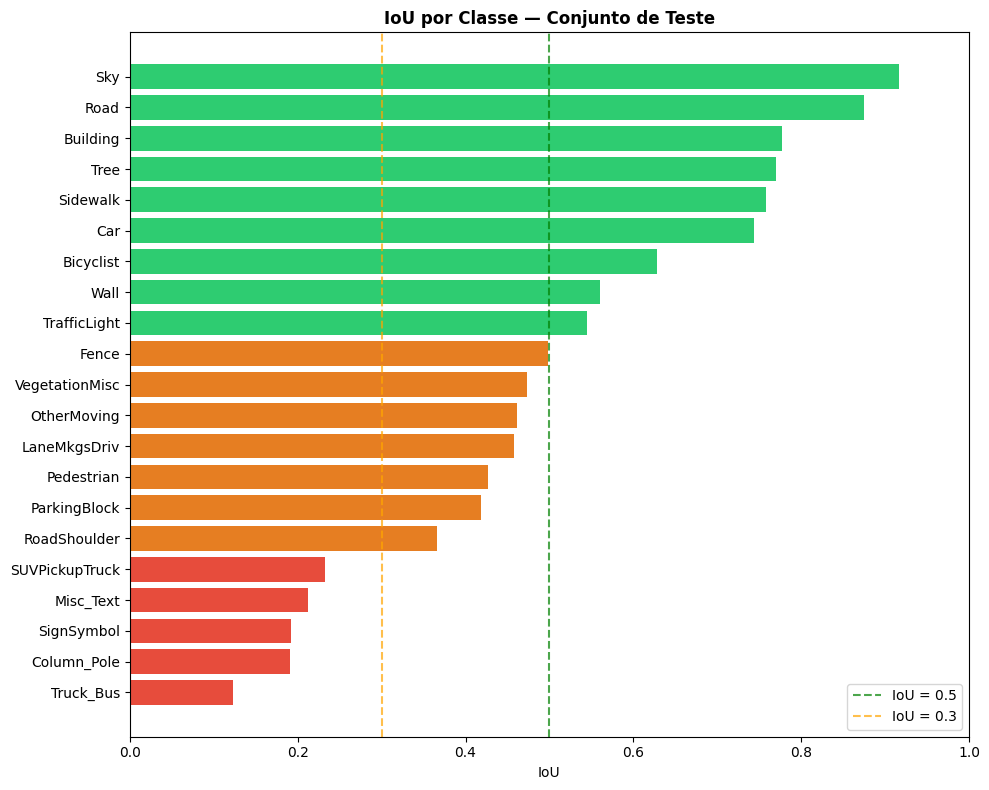

In [54]:
# === IoU POR CLASSE ===

df_iou = pd.DataFrame({
    "Classe" : CLASSES_VALIDAS,
    "IoU"    : iou_classes.cpu().numpy(),
}).sort_values("IoU", ascending=False).reset_index(drop=True)

print(f"\n{'Classe':<22} {'IoU':>6}")
print("-" * 30)
for _, row in df_iou.iterrows():
    barra = "█" * int(row["IoU"] * 20)
    print(f"  {row['Classe']:<20} {row['IoU']:.4f}  {barra}")

print("-" * 30)
print(f"  {'Média (Macro)':<20} {df_iou['IoU'].mean():.4f}")

# Visualização
fig, ax = plt.subplots(figsize=(10, 8))
cores = ["#2ecc71" if v >= 0.5 else "#e67e22" if v >= 0.3 else "#e74c3c"
         for v in df_iou["IoU"]]

ax.barh(df_iou["Classe"], df_iou["IoU"], color=cores)
ax.axvline(x=0.5, color="green",  linestyle="--", alpha=0.7, label="IoU = 0.5")
ax.axvline(x=0.3, color="orange", linestyle="--", alpha=0.7, label="IoU = 0.3")
ax.set_xlabel("IoU")
ax.set_title("IoU por Classe — Conjunto de Teste", fontweight="bold")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

Calculando matriz: 100%|██████████| 58/58 [01:59<00:00,  2.06s/it]


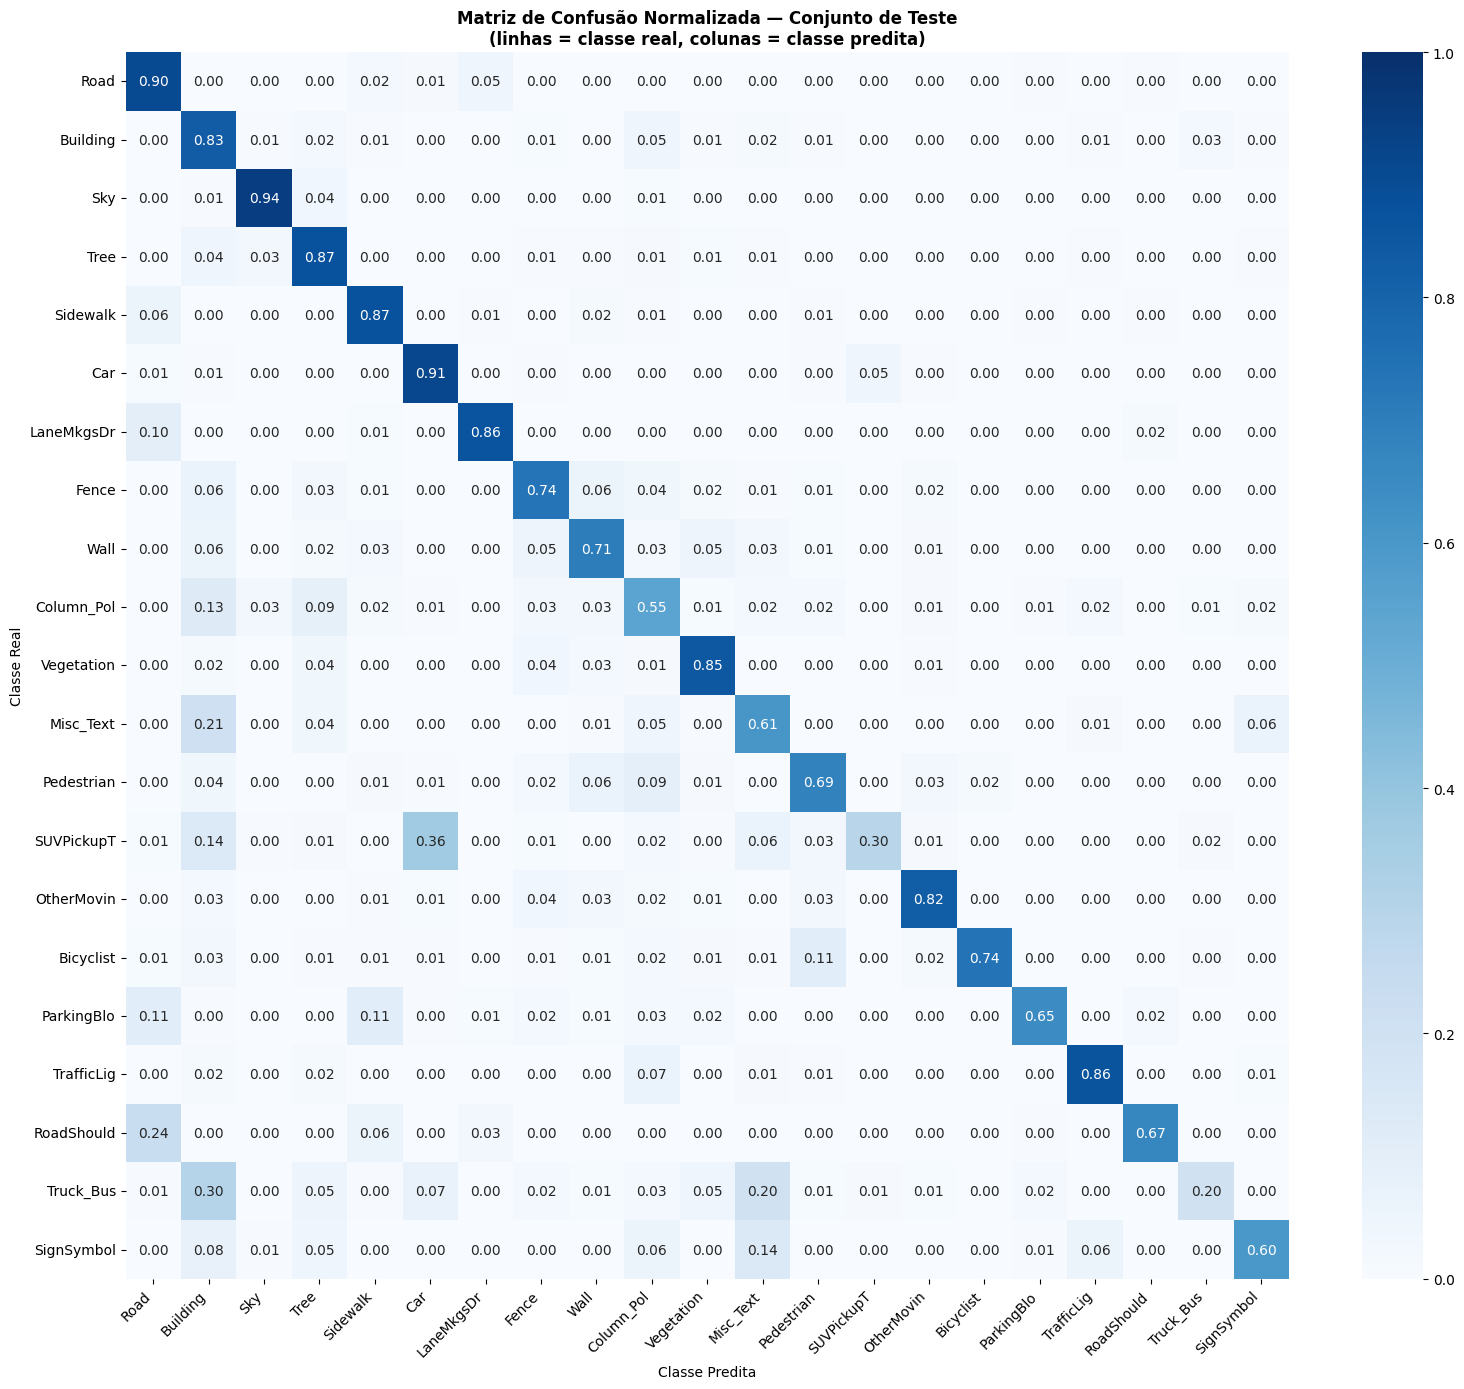

In [66]:
# === MATRIZ DE CONFUSÃO ===
from torchmetrics.classification import MulticlassConfusionMatrix

conf_matrix_metric = MulticlassConfusionMatrix(
    num_classes  = NUM_CLASSES,
    ignore_index = IGNORE_INDEX,
    normalize    = "true",  # normaliza por linha (proporção real)
).to(DEVICE)

with torch.no_grad():
    for imgs, mascaras in tqdm(dl_teste, desc="Calculando matriz"):
        imgs     = imgs.to(DEVICE)
        mascaras = mascaras.to(DEVICE)
        with autocast(device_type="cuda"):
            logits = model(imgs)
        preds = logits.argmax(dim=1)
        conf_matrix_metric.update(preds, mascaras)

conf_matrix = conf_matrix_metric.compute().cpu().numpy()

# Classes abreviadas para o gráfico
abrev = [c[:10] for c in CLASSES_VALIDAS]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    conf_matrix,
    annot   = True,
    fmt     = ".2f",
    cmap    = "Blues",
    xticklabels = abrev,
    yticklabels = abrev,
    ax      = ax,
    vmin    = 0,
    vmax    = 1,
)
ax.set_title("Matriz de Confusão Normalizada — Conjunto de Teste\n"
             "(linhas = classe real, colunas = classe predita)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Classe Real")
ax.set_xlabel("Classe Predita")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

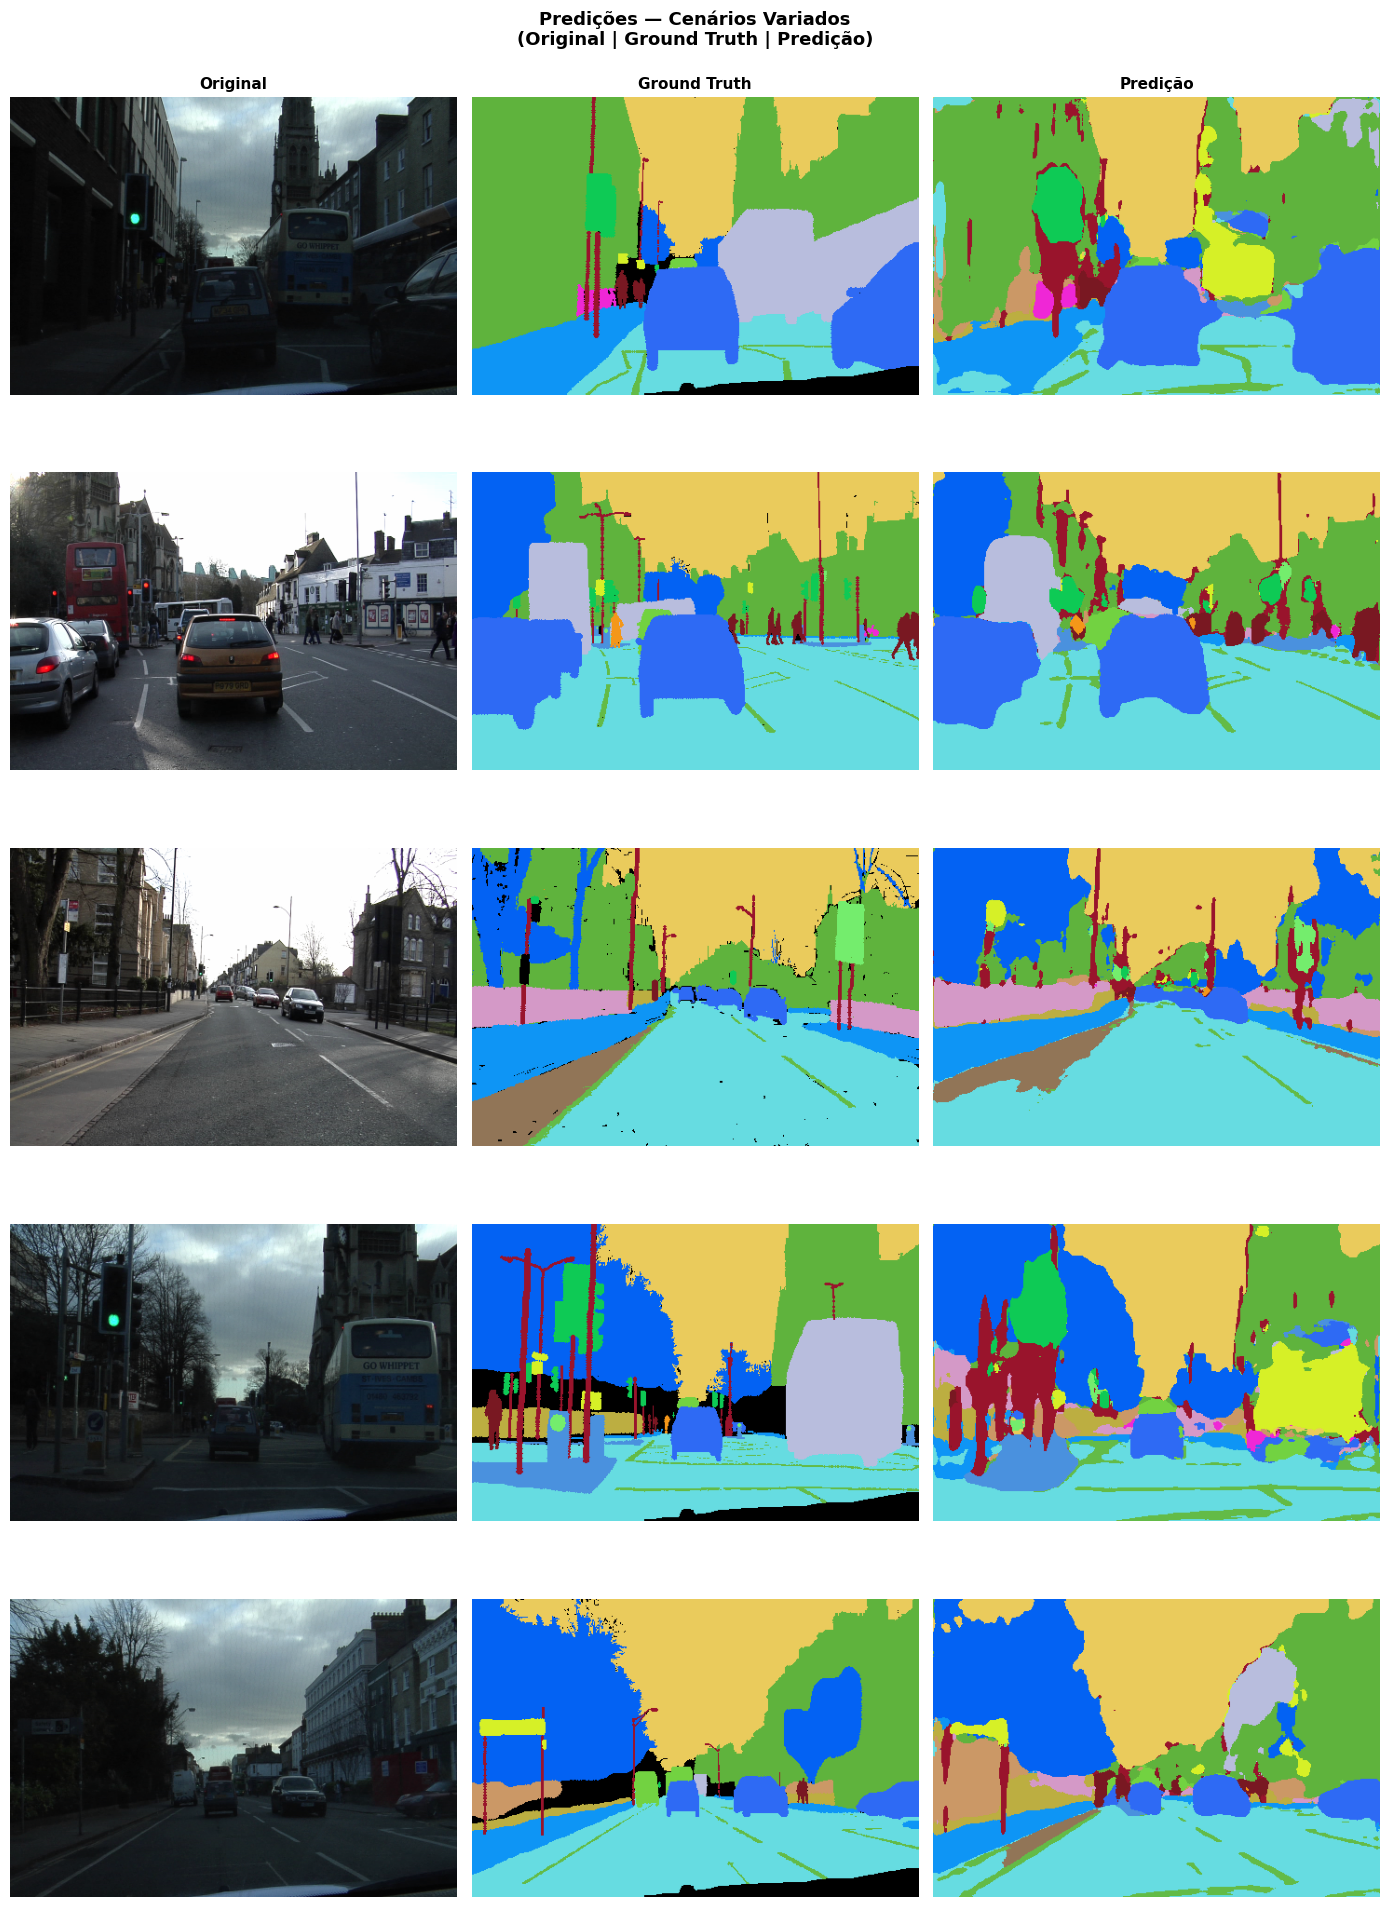

In [65]:
# === VISUALIZAÇÃO DE PREDIÇÕES — CENÁRIOS VARIADOS ===

def visualizar_predicao(img_path, msk_dir, model, titulo=""):
    msk_path = msk_dir / (img_path.stem + "_L.png")

    img_orig = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    msk_rgb  = np.array(Image.open(msk_path).convert("RGB"))
    msk_idx  = mask_rgb_para_indices(msk_rgb)

    aug        = transform_val_teste(image=img_orig, mask=msk_idx)
    img_tensor = aug["image"].unsqueeze(0).float().to(DEVICE)

    model.eval()
    with torch.no_grad():
        with autocast(device_type="cuda"):
            logits = model(img_tensor)
    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

    img_vis  = aug["image"].permute(1, 2, 0).numpy()
    img_vis  = (img_vis * STD + MEAN).clip(0, 1)
    msk_vis  = idx_para_cor(aug["mask"].numpy())
    pred_vis = idx_para_cor(pred)

    return img_vis, msk_vis, pred_vis, titulo


imgs_teste = sorted(DIR_TEST_IMG.glob("*.png"))

cenarios = [
    (DIR_TEST_IMG / "0001TP_006690.png",  "Seq. 1 — Cena urbana densa"),
    (DIR_TEST_IMG / "0016E5_04470.png",   "Seq. 2 — Tráfego variado"),
    (DIR_TEST_IMG / "Seq05VD_f00240.png", "Seq. 3 — Cena aberta"),
    (imgs_teste[10],                       "Caso extra — verificação geral"),
    (imgs_teste[25],                       "Caso extra — verificação geral"),
]

n = len(cenarios)
fig, axes = plt.subplots(n, 3, figsize=(14, n * 4))
fig.suptitle(
    "Predições — Cenários Variados\n(Original | Ground Truth | Predição)",
    fontsize=13, fontweight="bold"
)

for j, col in enumerate(["Original", "Ground Truth", "Predição"]):
    axes[0, j].set_title(col, fontsize=11, fontweight="bold")

for i, (img_path, titulo) in enumerate(cenarios):
    img_vis, msk_vis, pred_vis, label = visualizar_predicao(
        img_path, DIR_TEST_MSK, model, titulo
    )
    axes[i, 0].imshow(img_vis)
    axes[i, 1].imshow(msk_vis)
    axes[i, 2].imshow(pred_vis)

    for j in range(3):
        axes[i, j].axis("off")

    axes[i, 0].set_ylabel(label, fontsize=9, rotation=0,
                           labelpad=120, va="center")

plt.tight_layout()
plt.show()

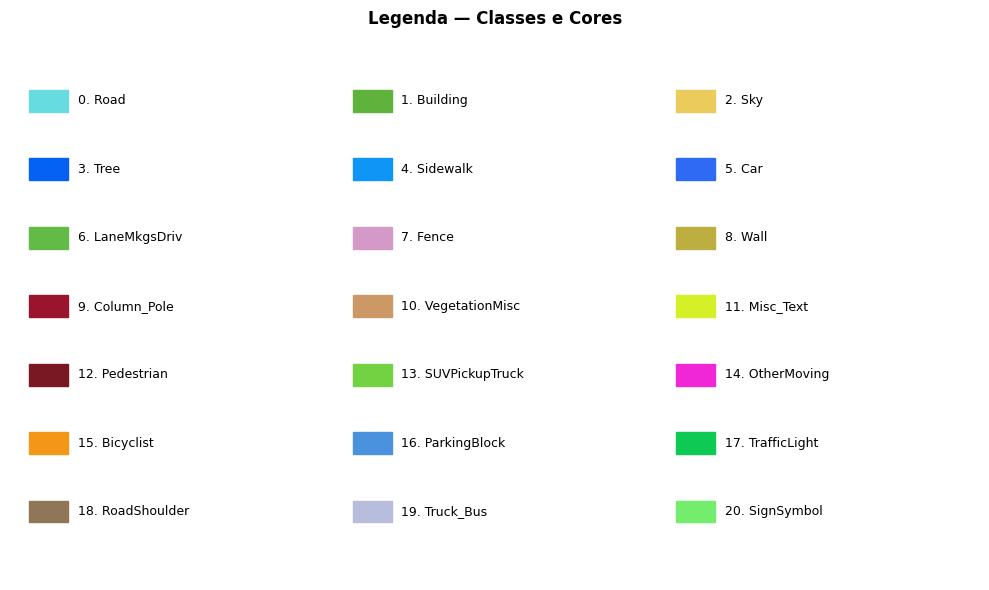

In [56]:
# === LEGENDA DAS CLASSES ===

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")
ax.set_title("Legenda — Classes e Cores", fontweight="bold", fontsize=12)

cols = 3
rows = (NUM_CLASSES + cols - 1) // cols

for idx, classe in enumerate(CLASSES_VALIDAS):
    col = idx % cols
    row = idx // cols
    cor = PALETA[idx] / 255.0
    x   = col / cols + 0.02
    y   = 1 - (row + 1) / (rows + 1)

    ax.add_patch(plt.Rectangle((x, y - 0.02), 0.04, 0.04, color=cor,
                                transform=ax.transAxes))
    ax.text(x + 0.05, y, f"{idx}. {classe}", transform=ax.transAxes,
            va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Conclusões

### Resultados Obtidos

O modelo U-Net com encoder ResNet-34 treinado por 30 épocas atingiu
os seguintes resultados no conjunto de teste:

| Métrica   | Valor  |
|-----------|--------|
| IoU Macro | 0.5061 |
| F1 / Dice | 0.6393 |
| Accuracy  | 0.7221 |

### O que o Modelo Aprendeu Bem

Classes grandes e visualmente distintas foram segmentadas com excelência.
Sky (IoU 0.92), Road (0.87), Building (0.78), Tree (0.77) e Car (0.74)
apresentaram resultados sólidos — o modelo aprendeu com clareza as
estruturas dominantes de cenas urbanas.

### Onde o Modelo Falhou e Por Quê

**Objetos finos e pequenos** foram o maior desafio. Column_Pole (0.19)
e SignSymbol (0.19) ocupam poucos pixels e a arquitetura U-Net perde
detalhes finos durante a compressão do encoder.

**Confusão entre veículos** foi o segundo problema principal. Truck_Bus
(0.12) e SUVPickupTruck (0.23) são frequentemente classificados como
Car ou Building — o modelo aprende que é um veículo, mas não distingue
o subtipo com confiança.

**Cenas com baixa iluminação** degradam a performance. O dataset CamVid
tem predominância de cenas nubladas e o modelo não generalizou bem para
variações extremas de luminosidade.

**RoadShoulder vs Road** (0.37) ilustra um limite semântico: as duas
classes são visualmente quase idênticas, a diferença é sutil até para
humanos.

### Decisões Técnicas que Fizeram Diferença

- **Análise pixel-level** revelou desequilíbrio severo (Road 28% vs
  SignSymbol 0.11%) e guiou o cálculo de pesos de classe
- **Remoção de classes com < 0.1% dos pixels** eliminou ruído sem
  perder informação relevante
- **ignore_index para Void** impediu que regiões sem anotação
  distorcessem o aprendizado
- **Mixed Precision (AMP)** viabilizou o treinamento na GPU de 4GB
  sem comprometer a qualidade
- **Métricas corretas (torchmetrics)** substituíram a implementação
  quebrada da versão anterior, que retornava IoU = -1.12

### Limitações e Próximos Passos

Os resultados atuais são honestos e representativos, mas há espaço
claro para evolução. Uma próxima versão poderia explorar a arquitetura
DeepLabV3+ com encoder EfficientNet-B4, augmentações específicas para
baixa iluminação, e técnicas como OHEM para focar o treino nos exemplos
mais difíceis. A expectativa é atingir IoU entre 0.60 e 0.65.